In [1]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%load_ext autoreload
%autoreload 2
ROOT_PATH = "Z:/data/PROC"
RET_PATH = "D:/retinotopy/aligned_xy/behav"
MDL_PATH = "D:/mouseobj/Passive"

In [73]:
db_ = []
#iexp = 0
db_.append({'mname': 'VG56', 'datexp': '2026_07_13', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG58', 'datexp': '2026_07_14', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG59', 'datexp': '2026_07_14', 'blk':'2','stim':'short3'})
db_.append({'mname': 'VG69', 'datexp': '2026_08_12', 'blk':'4','stim':'8x4textures'})

In [3]:
import mat73
import os
def load_timeline(db):    
    mname, datexp, blk = db['mname'], db['datexp'], db['blk']
    root = os.path.join('Z:/data/PROC', mname, datexp, blk)
    fname     = 'Timeline_%s_%s_%s_RAW.mat'%(mname, datexp, blk) 
    fnamepath = os.path.join(root, fname) 
    data = mat73.loadmat(fnamepath)
    return data

In [4]:
mice = []
for item in db_:
    m = utils.load_mouse(item['mname'], item['datexp'], item['blk'], mdl_path=MDL_PATH)
    mice.append(m)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\Passive\VG56\2026_07_13\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'isred', 'subset_stim', 'neurons_atframes', 'csig'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\Passive\VG58\2026_07_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'isred', 'subset_stim', 'neurons_atframes', 'csig'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\Passive\VG59\2026_07_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', 

In [74]:
timeline = load_timeline(db_[3])

ERROR:root:ERROR: MATLAB type not supported: internal.Serialport, (uint32)
ERROR:root:ERROR: MATLAB type not supported: icomm.mqtt.Client, (uint32)


In [68]:
from scipy.signal import medfilt, find_peaks

In [69]:
from matplotlib.widgets import Slider

In [70]:
%matplotlib widget

In [80]:
pup = timeline["TL"]["beh"]["pup"]
pup_median = medfilt(pup[2,:], 9) # pupil should be 1, 2 and 3?

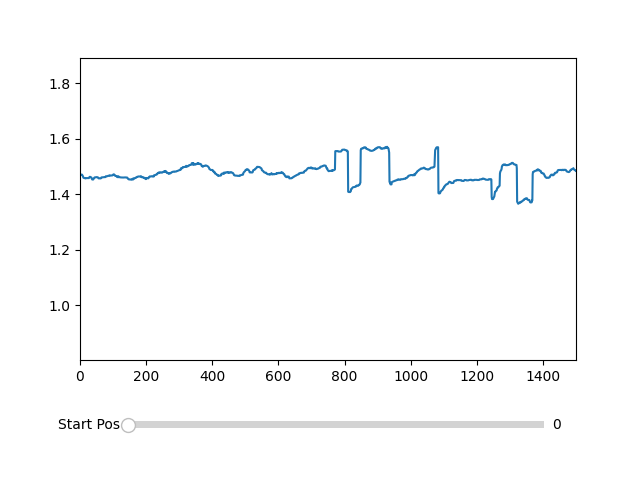

In [81]:
plot, Axis = plt.subplots()
plt.subplots_adjust(bottom=0.25)
x = np.arange(len(pup_median))
l = plt.plot(x, pup_median)
window_size = 1500

Axis.set_xlim(0, window_size)
Axis.set_ylim(np.min(pup_median), np.max(pup_median))
slider_color = 'White'
max_slider_val = max(0, len(pup_median) - window_size)

axis_position = plt.axes([0.2, 0.1, 0.65, 0.03], facecolor=slider_color)
slider_position = Slider(
    axis_position, 
    'Start Pos', 
    0, 
    max_slider_val, 
    valinit=0, 
    valstep=1
)
def update(val):
    pos = int(slider_position.val)
    Axis.set_xlim(pos, pos + window_size)
    plot.canvas.draw_idle()
slider_position.on_changed(update)
plt.show()